# Load Packages and Data

In [ ]:
import os
import sys
sys.path.append(os.getcwd())
sys.path.append(f"{os.getcwd()}/..")

from gp import GaussianProcess
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy as jsp
import numpy as np

import time
import matplotlib.pyplot as plt
import dill

jax.config.update('jax_enable_x64', False)

In [ ]:
X_train = jnp.load('../data/X_train.npy')
y_train = jnp.load('../data/y_train.npy')

obs_count = jnp.load('../data/obs_count.npy')
obs_sse = jnp.load('../data/obs_sse.npy')

X_test = jnp.load('../data/X_test.npy')

In [ ]:
# X_train = jnp.load('../gridsearch/X_train.npy')
# y_train = jnp.load('../gridsearch/y_train.npy')
# obs_count = jnp.load('../gridsearch/obs_count.npy')
# obs_sse = jnp.load('../gridsearch/obs_sse.npy')

# X_val = jnp.load('../gridsearch/X_test.npy')
# y_val = jnp.load('../gridsearch/y_test.npy')

# Configure and Run GP

In [ ]:
indoor_mask = X_train[:,2].astype(bool)
outdoor_mask = ~X_train[:,2].astype(bool)

indoor_mean = y_train[indoor_mask].mean()
outdoor_mean = y_train[outdoor_mask].mean()

def m(obs):
    return obs[2] * indoor_mean + (1 - obs[2]) * outdoor_mean

ls_xy, ls_z, os_xyz, ls_t, os_t, ls_ap = [0.045, 0.20, 25.0, 50.0, 5.0, 1.0]
ls_xyz = jnp.array([ls_xy, ls_xy, ls_z])

def K(obs1, obs2):
    d_xyz = ((obs1[:3] - obs2[:3])**2 / (2*ls_xyz**2)).sum()
    d_ap = jnp.where(obs1[4] == obs2[4], 0.0, 1.0) / (2*ls_ap**2)
    d_t = (obs1[3] - obs2[3])**2
    return os_xyz * jnp.exp(- (d_xyz + d_ap)) + \
        os_t * jnp.exp(- d_t / (2*ls_t**2))

In [ ]:
GP = GaussianProcess(m, K)
GP.fit(X_train, y_train, obs_count, obs_sse)

In [ ]:
start = time.time()
chain = GP.gibbs(chains=2, samples=111, calibration_iters=10, jitter_factor=5)
end = time.time()
print(f"Elapsed: {end - start}")

In [ ]:
GP.jitter

In [ ]:
# y_hat, _ = GP.predict(X_val, chain[1][:,20:], method='sequential')
# jnp.mean((y_val - y_hat.mean(axis=0))**2)

In [ ]:
indoor_vars = chain[1][:,:,1]
outdoor_vars = chain[1][:,:,0]

In [ ]:
plt.plot(range(indoor_vars.shape[1]), indoor_vars[0], label='Indoor')
plt.plot(range(outdoor_vars.shape[1]), outdoor_vars[0], label="Outdoor")
plt.xlabel('Gibbs Step'); plt.ylabel('Posterior Variance Samples')
plt.title('Gibbs Sampler Mixing'); plt.legend()
plt.savefig('gibbs_mixing.png', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
GP.IG_posteriors

In [ ]:
cov_chains = chain[1][:,10::,:]
cov_chains.shape

In [ ]:
cov_chains

# Predict on New Data

In [16]:
X_new = jnp.load('../data/X_test.npy')
with open('../data/osm_context.pkl', 'rb') as f:
    osm_context = dill.load(f)
wlon_train, wlat_train = np.load('../data/world_train.npy').T
wlon_test, wlat_test = np.load('../data/world_test.npy').T

In [17]:
start = time.time()
new_means, new_vars = GP.predict(X_new, cov_chains, method='sequential')
end = time.time()
print(f"Elapsed: {end - start}")

Elapsed: 19.861643314361572


In [21]:
mean_post = new_means.mean(axis=0)
var_post = new_means.var(axis=0) + new_vars.mean(axis=0)

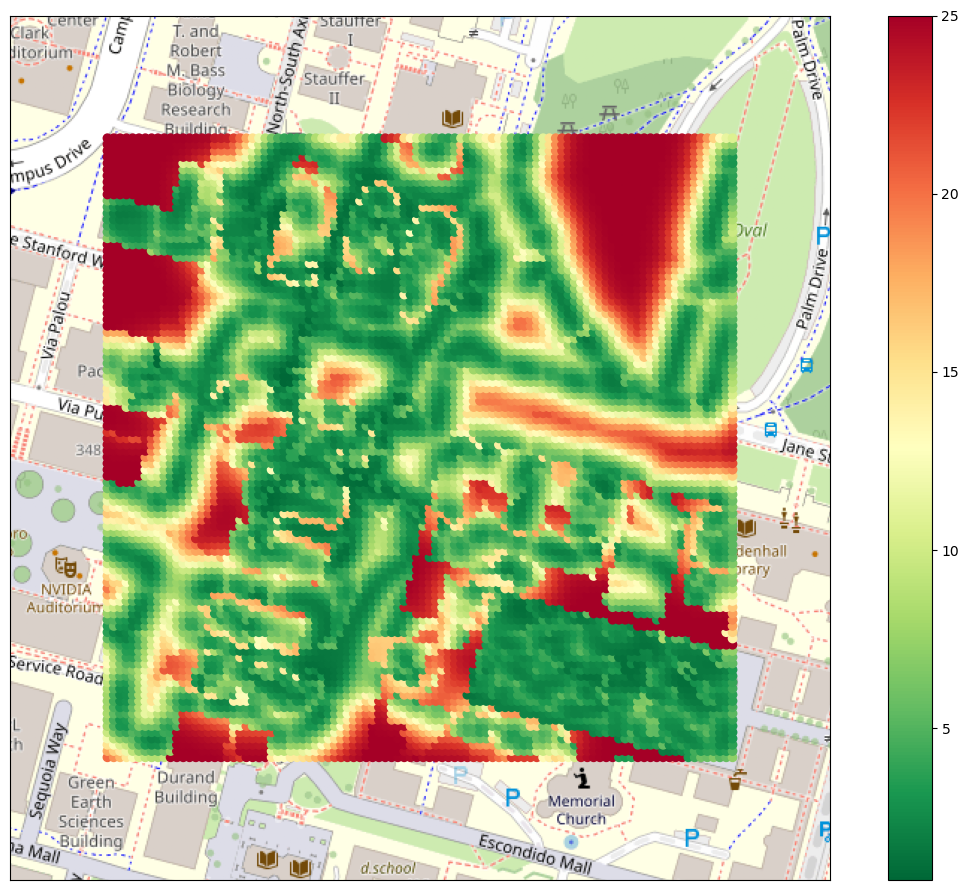

In [32]:
vmax = jnp.quantile(y_train, 0.975)
vmin = jnp.quantile(y_train, 0.025)

vmax = jnp.quantile(var_post, 1.)
vmin = jnp.quantile(var_post, 0.)

base_fig, base_ax, osm_metadata = osm_context.generate_base_axis(draw_buildings=False)

sc = base_ax.scatter(wlon_test, wlat_test, c=var_post, cmap="RdYlGn_r", vmin=vmin, vmax=vmax)

# tr = base_ax.scatter(wlon_train, wlat_train, c=y_train, cmap="RdYlGn",
#                 vmin=vmin, vmax=vmax, alpha=1)
plt.ticklabel_format(style='plain', axis='both', useOffset=False)

plt.colorbar(sc)
plt.tight_layout()

# plt.savefig('posterior_variance.png', dpi=400)

## Cross-validation MSE

In [ ]:
CV_SPLIT_TYPES = ['rand', 'geo']
CV_N_SPLITS = 5
CV_CHAINS = 2
CV_SAMPLES = 111
CV_CALIBRATION_ITERS = 30
CV_BURN_IN = 10
CV_JITTER_FACTOR = 5
CV_KEY_SEED = 305
CV_PREDICT_METHOD = 'sequential'
CV_RESULTS_PATH = 'cv_gibbs_mse_results.csv'


def make_split_gp(X_split, y_split):
    indoor_mask = X_split[:, 2].astype(bool)
    outdoor_mask = ~indoor_mask

    indoor_mean = y_split[indoor_mask].mean()
    outdoor_mean = y_split[outdoor_mask].mean()

    def m_split(obs):
        return obs[2] * indoor_mean + (1 - obs[2]) * outdoor_mean

    return GaussianProcess(m_split, K)


def evaluate_cv_split(split_type, split_idx):
    split_dir = f'../cv/{split_type}'

    X_cv_train = jnp.load(f'{split_dir}/X_train_{split_idx}.npy')
    y_cv_train = jnp.load(f'{split_dir}/y_train_{split_idx}.npy')
    obs_count_cv_train = jnp.load(f'{split_dir}/obs_count_train_{split_idx}.npy')
    obs_sse_cv_train = jnp.load(f'{split_dir}/obs_sse_train_{split_idx}.npy')

    X_cv_test = jnp.load(f'{split_dir}/X_test_{split_idx}.npy')
    y_cv_test = jnp.load(f'{split_dir}/y_test_{split_idx}.npy')

    split_gp = make_split_gp(X_cv_train, y_cv_train)
    split_gp.fit(X_cv_train, y_cv_train, obs_count_cv_train, obs_sse_cv_train)

    key_offset = 0 if split_type == 'rand' else CV_N_SPLITS

    start = time.time()
    chain = split_gp.gibbs(
        key=jr.PRNGKey(CV_KEY_SEED + key_offset + split_idx),
        chains=CV_CHAINS,
        samples=CV_SAMPLES,
        calibration_iters=CV_CALIBRATION_ITERS,
        jitter_factor=CV_JITTER_FACTOR,
    )
    fit_elapsed = time.time() - start

    cov_chains = chain[1][:, CV_BURN_IN:, :]
    start = time.time()
    pred_means, pred_vars = split_gp.predict(X_cv_test, cov_chains, method=CV_PREDICT_METHOD)
    predict_elapsed = time.time() - start

    y_hat = pred_means.mean(axis=0)
    mse = jnp.mean((y_cv_test - y_hat) ** 2)

    return {
        'split_type': split_type,
        'split_idx': split_idx,
        'n_train': int(X_cv_train.shape[0]),
        'n_test': int(X_cv_test.shape[0]),
        'mse': float(mse),
        'fit_elapsed': fit_elapsed,
        'predict_elapsed': predict_elapsed,
        'jitter': float(split_gp.jitter),
    }


cv_results = []
for split_type in CV_SPLIT_TYPES:
    for split_idx in range(CV_N_SPLITS):
        print(f'Fitting {split_type} split {split_idx}')
        result = evaluate_cv_split(split_type, split_idx)
        cv_results.append(result)
        print(
            f"{split_type} split {split_idx}: "
            f"MSE={result['mse']:.4f}, "
            f"fit={result['fit_elapsed']:.1f}s, "
            f"predict={result['predict_elapsed']:.1f}s"
        )

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.to_csv(CV_RESULTS_PATH, index=False)
cv_results_df

## Geo Fold 2 GP Surface

In [ ]:
import wifiplotting

GEO_VIS_SPLIT_IDX = 2
GEO_VIS_LAT_BINS = 20
GEO_VIS_LON_BINS = 20

geo_fold_dir = "../cv/geo"
X_geo_fold_train = jnp.load(f"{geo_fold_dir}/X_train_{GEO_VIS_SPLIT_IDX}.npy")
y_geo_fold_train = jnp.load(f"{geo_fold_dir}/y_train_{GEO_VIS_SPLIT_IDX}.npy")
obs_count_geo_fold_train = jnp.load(f"{geo_fold_dir}/obs_count_train_{GEO_VIS_SPLIT_IDX}.npy")
obs_sse_geo_fold_train = jnp.load(f"{geo_fold_dir}/obs_sse_train_{GEO_VIS_SPLIT_IDX}.npy")

X_geo_fold_test = jnp.load(f"{geo_fold_dir}/X_test_{GEO_VIS_SPLIT_IDX}.npy")
y_geo_fold_test = jnp.load(f"{geo_fold_dir}/y_test_{GEO_VIS_SPLIT_IDX}.npy")

geo_fold_gp = make_split_gp(X_geo_fold_train, y_geo_fold_train)
geo_fold_gp.fit(
    X_geo_fold_train,
    y_geo_fold_train,
    obs_count_geo_fold_train,
    obs_sse_geo_fold_train,
)

geo_fold_chain = geo_fold_gp.gibbs(
    key=jr.PRNGKey(CV_KEY_SEED + CV_N_SPLITS + GEO_VIS_SPLIT_IDX),
    chains=CV_CHAINS,
    samples=CV_SAMPLES,
    calibration_iters=CV_CALIBRATION_ITERS,
    jitter_factor=CV_JITTER_FACTOR,
)
geo_fold_cov_chains = geo_fold_chain[1][:, CV_BURN_IN:, :]

X_geo_fold_grid = jnp.load("../data/X_test.npy")
geo_fold_grid_means, geo_fold_grid_vars = geo_fold_gp.predict(
    X_geo_fold_grid,
    geo_fold_cov_chains,
    method=CV_PREDICT_METHOD,
)
geo_fold_grid_pred = np.asarray(geo_fold_grid_means.mean(axis=0))

geo_fold_test_means, geo_fold_test_vars = geo_fold_gp.predict(
    X_geo_fold_test,
    geo_fold_cov_chains,
    method=CV_PREDICT_METHOD,
)
geo_fold_test_pred = np.asarray(geo_fold_test_means.mean(axis=0))

with open("../data/osm_context.pkl", "rb") as f:
    geo_fold_context = dill.load(f)

geo_fold_coord_all = np.load("../data/coord_train.npy")
geo_fold_y_all = np.load("../data/y_train.npy")
geo_fold_train_idx = np.load(f"{geo_fold_dir}/train_idx_{GEO_VIS_SPLIT_IDX}.npy")
geo_fold_test_idx = np.load(f"{geo_fold_dir}/test_idx_{GEO_VIS_SPLIT_IDX}.npy")
geo_fold_world_train = np.load(f"{geo_fold_dir}/world_train_{GEO_VIS_SPLIT_IDX}.npy")
geo_fold_world_test = np.load(f"{geo_fold_dir}/world_test_{GEO_VIS_SPLIT_IDX}.npy")
geo_fold_world_grid = np.load("../data/world_test.npy")

geo_fold_lat_edges, geo_fold_lon_edges, geo_fold_lat_grid, geo_fold_lon_grid, geo_fold_in_grid = wifiplotting.geo_vis_grid_from_lonlat(
    geo_fold_coord_all[:, 0],
    geo_fold_coord_all[:, 1],
    GEO_VIS_LAT_BINS,
    GEO_VIS_LON_BINS,
)
geo_fold_heldout_cells = wifiplotting.geo_vis_cells_from_indices(
    geo_fold_test_idx,
    geo_fold_lat_grid,
    geo_fold_lon_grid,
    geo_fold_in_grid,
)

geo_fold_vmin = np.quantile(geo_fold_y_all, 0.025)
geo_fold_vmax = np.quantile(geo_fold_y_all, 0.975)

fig, ax, surface = wifiplotting.plot_geo_fold_surface(
    geo_fold_context,
    geo_fold_world_grid,
    geo_fold_grid_pred,
    world_train=geo_fold_world_train,
    y_train=y_geo_fold_train,
    world_test=geo_fold_world_test,
    y_test=y_geo_fold_test,
    lat_edges=geo_fold_lat_edges,
    lon_edges=geo_fold_lon_edges,
    heldout_cells=geo_fold_heldout_cells,
    vmin=geo_fold_vmin,
    vmax=geo_fold_vmax,
    model_label="GP",
    split_idx=GEO_VIS_SPLIT_IDX,
    surface_size=10,
    surface_alpha=0.8,
    show_train=True,
    test_size=34,
)

geo_fold_test_resid, geo_fold_test_sq_err, geo_fold_test_mse, top_error_local_idx, geo_fold_top_errors = wifiplotting.compute_heldout_error_summary(
    y_geo_fold_test,
    geo_fold_test_pred,
    test_idx=geo_fold_test_idx,
    coord_all=geo_fold_coord_all,
    X_test=X_geo_fold_test,
    top_n=4,
)
top_error_n = len(top_error_local_idx)
top_error_global_idx = geo_fold_test_idx[top_error_local_idx]

fig, ax = wifiplotting.plot_heldout_error_hist(
    geo_fold_test_sq_err,
    geo_fold_test_mse,
    top_error_local_idx,
    split_idx=GEO_VIS_SPLIT_IDX,
    model_label="GP",
    top_n=top_error_n,
)

fig, ax, top_scatter = wifiplotting.plot_top_heldout_errors_map(
    geo_fold_context,
    geo_fold_world_test,
    geo_fold_test_sq_err,
    top_error_local_idx,
    lat_edges=geo_fold_lat_edges,
    lon_edges=geo_fold_lon_edges,
    heldout_cells=geo_fold_heldout_cells,
    split_idx=GEO_VIS_SPLIT_IDX,
    model_label="GP",
    top_n=top_error_n,
    cell_style={"edgecolor": "black"},
)

geo_fold_top_errors
